In [5]:
import xarray as xr
import numpy as np
import jax.numpy as jnp

from scipy.signal.windows import tukey

import sys
sys.path.append('./../subroutine')
from rfft2 import rfft2, irfft2
from rel_err import rel_err
from isospec_rfft import isospec_rfft

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import cmocean.cm as cmo
plt.style.use('/mnt/c/Ryan_Data/Tools/Python_Tool/ryan_mplstyle.mplstyle')

#####################################
import jax.numpy as jnp
import jaxopt

#####################################
from scipy.stats import wasserstein_distance, wasserstein_distance_nd

In [7]:
import scipy.io as sio

ds = sio.loadmat("../data/data_matlab/SQGp1MATLAB.mat")
ds_truth = xr.open_dataset("../data/data_matlab/processed/truth.nc")
# ds_lpfilter = xr.open_dataset("data/data_channel/processed/Fourier_lpfilter.nc")
# ds_GeoBal = xr.open_dataset("data/data_channel/processed/Geo_Balanced.nc")

phi0__ = rfft2(ds['phi0'])

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [8]:
ds

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Feb 25 21:25:43 2025',
 '__version__': '1.0',
 '__globals__': [],
 'cycloterm': array([[-0.04740199, -0.05624791, -0.06342359, ..., -0.02129708,
         -0.02962104, -0.03831807],
        [-0.04503982, -0.05436299, -0.06260461, ..., -0.01974059,
         -0.02732674, -0.03582298],
        [-0.0433977 , -0.05295775, -0.06166919, ..., -0.01691697,
         -0.0248744 , -0.0338429 ],
        ...,
        [-0.04584495, -0.05376233, -0.05620714, ...,  0.00354701,
         -0.01688736, -0.03336729],
        [-0.04953624, -0.05755137, -0.06146636, ..., -0.01104706,
         -0.02601175, -0.03880915],
        [-0.04942711, -0.05780001, -0.06345475, ..., -0.01901085,
         -0.02977174, -0.03987029]]),
 'k1_': array([[ 0.  ,  0.32,  0.64,  0.96,  1.28,  1.6 ,  1.92,  2.24,  2.56,
          2.88,  3.2 ,  3.52,  3.84,  4.16,  4.48,  4.8 ,  5.12,  5.44,
          5.76,  6.08,  6.4 ,  6.72,  7.04,  7.36,  7.68,  8.  ,  8.32

In [9]:
x = ds_truth.x.values
y = ds_truth.y.values

In [10]:
press_lpfilter = ds_truth.Eta.values

In [11]:
f = ds_truth.f.values

Ro = 1
Ld = 1
Ud = Ro*Ld*f

In [12]:
dui = y[1,0]-y[0,0]

XC_Ld = ds_truth.x.values/Ld
YC_Ld = ds_truth.y.values/Ld
kx_Ld = np.fft.rfftfreq(press_lpfilter.shape[1],d=dui/Ld)*(2*np.pi)
ky_Ld =  np.fft.fftfreq(press_lpfilter.shape[0],d=dui/Ld)*(2*np.pi)

print(kx_Ld[1])

0.3200000000000034


In [13]:
press_lpndim = press_lpfilter/(f*Ud*Ld)
press_lpndim -= np.mean(press_lpndim)

print(np.std(press_lpndim))
print(np.std(press_lpndim)*kx_Ld[1]**2*Ro)

0.34450718429818467
0.03527753567213486


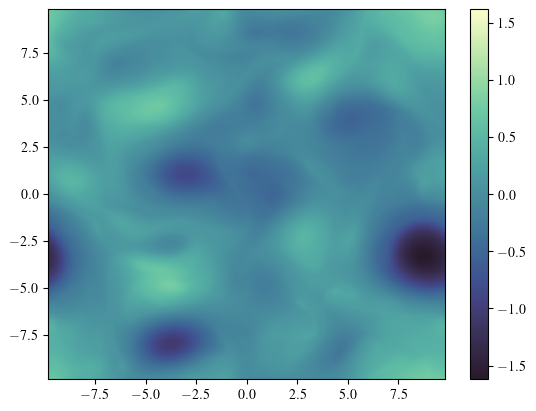

In [14]:
plt.pcolor(XC_Ld,YC_Ld,press_lpndim, cmap=cmo.deep_r, norm=colors.CenteredNorm())
plt.colorbar()

In [15]:
kx = kx_Ld; ky = ky_Ld
kx_mat, ky_mat = jnp.meshgrid(kx, ky)
K2 = (kx_mat**2+ky_mat**2)
Ka = jnp.sqrt(K2)
Kaa = Ka.at[0,0].set(0)
# Kaa = Ka
Kn = 1/(Ka.at[0,0].set(1e16))
Kn2 = 1/(K2.at[0,0].set(1e16))

###
press_lpndim__ = rfft2(press_lpndim)

In [16]:
Kaa.at[0,0].set(12000)
Kaa.max()

Array(115.85237, dtype=float32)

In [17]:
# lp_filter is just antialiasing here

lp_filter = jnp.ones(Ka.shape)
lp_filter = lp_filter.at[Ka>Ka[0,-1]/2.1].set(0)

In [19]:
def ZETA_QG__(phi0s__):
    phi0s__ *= lp_filter
    
    phi0s_xx__ = (phi0s__*-1*kx_Ld**2)
    phi0s_yy__ = ((phi0s__.T*-1*ky_Ld**2).T)

    zeta_f_SI = (phi0s_xx__+phi0s_yy__)
    return zeta_f_SI

In [20]:
def CYCLO_TERM_zeta__(phi0s__):
    phi0s__ *= lp_filter

    phi0s_xx = irfft2(phi0s__*-1*kx**2)
    phi0s_yy = irfft2((phi0s__.T*-1*ky**2).T)
    phi0s_xy = irfft2(phi0s__*-1*jnp.outer(ky,kx))

    return rfft2(2*(phi0s_xx*phi0s_yy-phi0s_xy**2))*lp_filter**1

def CYCLO_TERM__(phi0s__):
    return - CYCLO_TERM_zeta__(phi0s__)*Kn2*1

In [23]:
# New version of zeta_1 calculation, a copy of Shafer's MARLAB code

eps = 0.2
aa_val = 2

def U_0p1__(phi0s__):
    
    Ka0 = Ka.at[0,0].set(0)
    Kn = (1/Ka).at[0,0].set(0)

    b__ = phi0s__*Ka0
    b = irfft2(b__)
    
    # phi0s_x = irfft2(phi0s__*1j*kx)
    phi0s_y = irfft2((phi0s__.T*1j*ky).T)

    # bx = irfft2(b_k__*1j*kx)
    by = irfft2((b__.T*1j*ky).T)
    bz = irfft2(b__*Ka0)

    # Rxk__ = rfft2(b*phi0s_x)*Ka
    Ryk__ = rfft2(b*phi0s_y)*Ka
    # Ryk__ = Ryk__.at[Ka>Ka[0,-1]/aa_val].set(0)
    
    bbz__ = rfft2(b*bz)
    # bbz__ = bbz__.at[Ka>Ka[0,-1]/aa_val].set(0)
    Sk__  = bbz__*Kn;

    Up1 = -phi0s_y*(0+eps*bz) - 2*eps*by*b + eps*irfft2((Sk__.T*1j*ky).T + Ryk__)

    # return rfft2(Up1).at[Ka>Ka[0,-1]/2].set(0)
    return rfft2(Up1)

def V_0p1__(phi0s__):
    Ka0 = Ka.at[0,0].set(0)
    Kn = (1/Ka).at[0,0].set(0)

    b__ = phi0s__*Ka
    b = irfft2(b__)
    
    phi0s_x = irfft2(phi0s__*1j*kx)
    # phi0s_y = irfft2((phi0s__.T*1j*ky).T)

    bx = irfft2(b__*1j*kx)
    # by = irfft2((b_k__.T*1j*ky).T)
    bz = irfft2(b__*Ka)

    Rxk__ = rfft2(b*phi0s_x)*Ka
    # Rxk__ = Rxk__.at[Ka>Ka[0,-1]/aa_val].set(0)
    # Ryk__ = rfft2(b*phi0s_y)*Ka
    
    bbz__ = rfft2(b*bz)
    # bbz__ = bbz__.at[Ka>Ka[0,-1]/aa_val].set(0)
    Sk__  = bbz__*Kn;

    Vp1 = phi0s_x*(0+eps*bz) + 2*eps*bx*b - eps*irfft2(Sk__*1j*kx + Rxk__)

    # return rfft2(Vp1).at[Ka>Ka[0,-1]/2].set(0)
    return rfft2(Vp1)

def ZETAp1__(phi0s__):
    phi0s__ *= lp_filter
    
    zeta_fuv__ = (V_0p1__(phi0s__)*1j*kx - (U_0p1__(phi0s__).T*1j*ky).T)
    zeta_fuv__ /= eps

    return zeta_fuv__*lp_filter**1

In [24]:
def ZP1_TERM__(phi0s__):
    return - ZETAp1__(phi0s__)*Kn2*1

In [25]:
phi0__ = rfft2(ds['phi0'])
press_lpndim__ = rfft2(ds['ssh_full'])

phi0__ = phi0__*lp_filter
press_lpndim__ = press_lpndim__*lp_filter

Text(0.5, 0, '$k$ ')

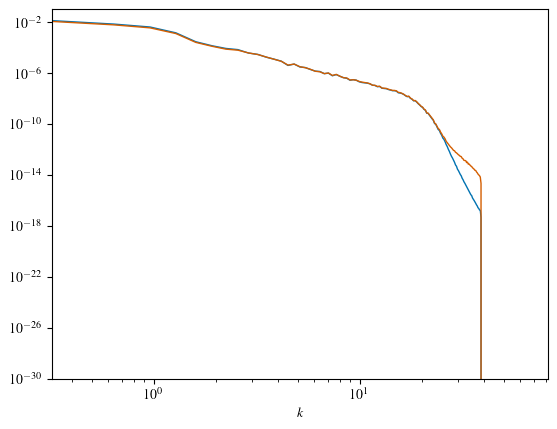

In [27]:
MATLABzetap1_spec = isospec_rfft( np.abs( phi0__ )**2 )
MATLABcyclo_spec = isospec_rfft( np.abs( press_lpndim__ )**2 )

k_ndim = ds['k1_'].ravel()
plt.loglog(k_ndim,MATLABzetap1_spec[1:],label="MATLAB $\zeta^1$ Spectrum")
plt.loglog(k_ndim,MATLABcyclo_spec[1:],label="MATLAB Cyclo term Spectrum")

plt.ylim([1e-30,1e-1])
plt.xlabel("$k$ ")
# plt.legend()

2.3683875e-05


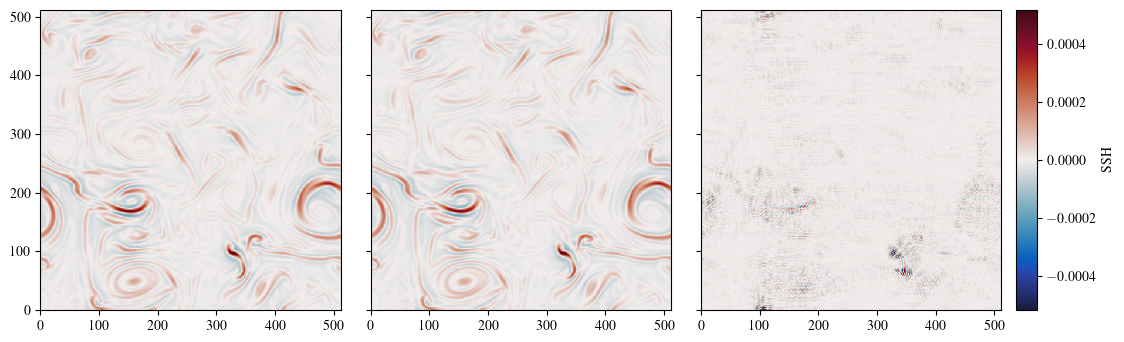

In [29]:
fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

matlab = irfft2(rfft2(ds['zeta1'])*lp_filter); matlab -= np.mean(matlab)
python_calc = irfft2(ZETAp1__(phi0__)); python_calc -= np.mean(python_calc)
diff = matlab-python_calc

im0 = grid[0].pcolor(matlab, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[0].cax.colorbar(im0)
im1 = grid[1].pcolor(python_calc, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[1].cax.colorbar(im1)
im2 = grid[2].pcolor(diff, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[2].cax.colorbar(im2)
cbar.set_label("SSH")

print(np.std(diff))

0.0034903262


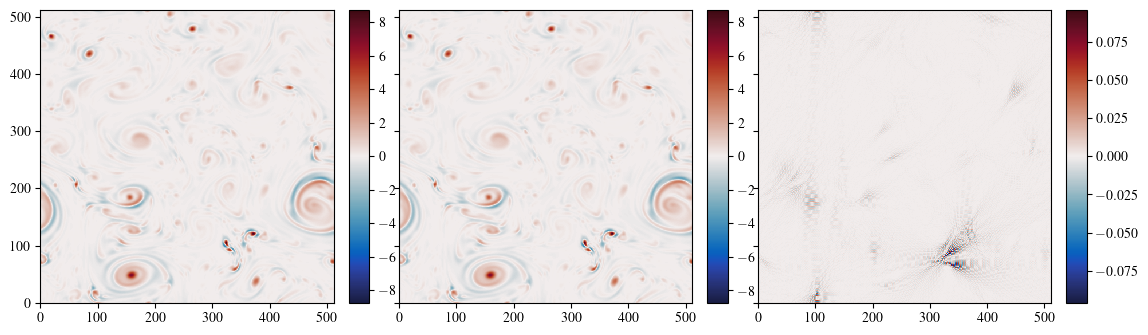

In [30]:
fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="each",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 1.4

matlab = 2*ds['cycloterm']; matlab -= np.mean(matlab)
python_calc = irfft2(CYCLO_TERM_zeta__(phi0__)); python_calc -= np.mean(python_calc)
diff = matlab-python_calc

im0 = grid[0].pcolor(matlab, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[0].cax.colorbar(im0)
im1 = grid[1].pcolor(python_calc, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[1].cax.colorbar(im1)
im2 = grid[2].pcolor(diff, cmap=cmo.balance, norm=colors.CenteredNorm())
cbar = grid[2].cax.colorbar(im2)
# cbar.set_label("SSH")

print(np.std(diff))

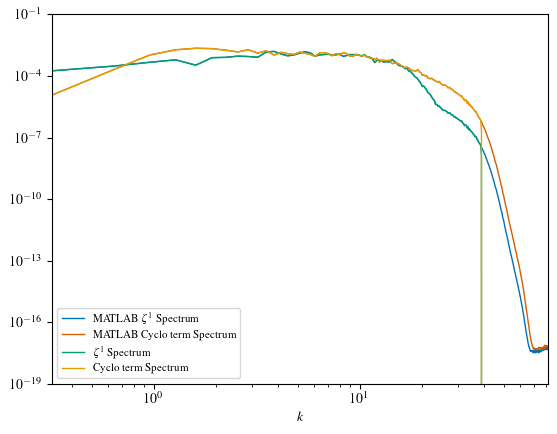

In [31]:
MATLABzetap1_spec = isospec_rfft( np.abs( rfft2(ds['zeta1']) )**2 )
MATLABcyclo_spec = isospec_rfft( np.abs( rfft2(ds['cycloterm'])*2 )**2 )
zetap1_spec = isospec_rfft( np.abs(ZETAp1__(phi0__))**2 )
cyclo_spec = isospec_rfft( np.abs(CYCLO_TERM_zeta__(phi0__))**2 )

k_ndim = np.arange(0,zetap1_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,MATLABzetap1_spec,label="MATLAB $\zeta^1$ Spectrum")
plt.loglog(k_ndim,MATLABcyclo_spec,label="MATLAB Cyclo term Spectrum")
plt.loglog(k_ndim,zetap1_spec,label="$\zeta^1$ Spectrum")
plt.loglog(k_ndim,cyclo_spec,label="Cyclo term Spectrum")

plt.ylim([1e-19,1e-1])
plt.xlabel("$k$ ")
plt.legend()

In [32]:
eps = 0.2

In [33]:
#### create fake data

press_truth__ = rfft2(ds['phi0'])
press_lpndim = ds['ssh_full']
press_lpndim__ = rfft2(press_lpndim)*lp_filter

Text(0.5, 0, '$k$ ')

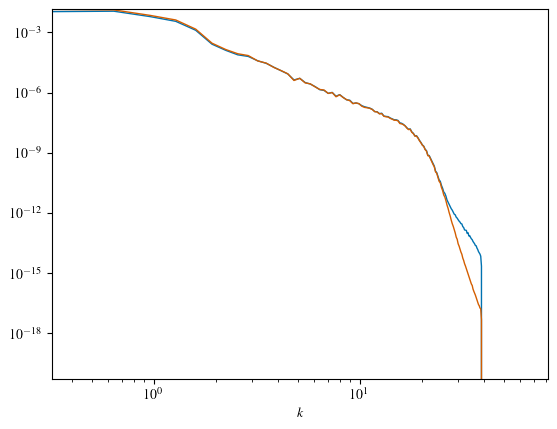

In [34]:
fakedata_spec = isospec_rfft( np.abs(press_lpndim__)**2 )
press_truth_spec = isospec_rfft( np.abs(press_truth__*lp_filter)**2 )
press_new_spec = isospec_rfft( np.abs(press_truth__-press_lpndim__)**2 )

k_ndim = np.arange(0,zetap1_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,fakedata_spec,label="Spectrum")
plt.loglog(k_ndim,press_truth_spec,label="Spectrum")
# plt.loglog(k_ndim,press_new_spec,label="Spectrum")

# plt.ylim([1e-7,1e-2])
plt.xlabel("$k$ ")
# plt.legend()

In [35]:
def err(params):

    params__ = rfft2(params)
    
    cyclo_corr = CYCLO_TERM__(params__)
    zp1_corr = ZP1_TERM__(params__)

    err_spec = (1+(Kaa**(2)))*lp_filter
    # err_spec = 1
    
    return jnp.sum( jnp.abs(press_lpndim__-params__-eps*(cyclo_corr+zp1_corr))**2*err_spec )

In [ ]:
# Can swap out minimization algorithm here
solver = jaxopt.LBFGS(fun=err, maxiter=1000, tol=1e-10)
# solver = jaxopt.ArmijoSGD(fun=err, maxiter=300, tol=1e-3)

In [37]:
res = solver.run(press_lpndim)
# res = solver.run(params__)

/home/ryan_wsl2/mambaforge/envs/PODAC/lib/python3.11/site-packages/jaxopt/_src/lbfgs.py:119: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  fun = lambda leaf: jnp.zeros((history_size,) + leaf.shape, dtype=leaf.dtype)


In [38]:
params, state = res;
print(state[0])
print(err(press_lpndim))
# print(state[1])
print(err(params)/err(press_lpndim))

params__ = rfft2(params)

1000
0.0019123686
0.00031896526


In [39]:
totp1pres__ = params__*lp_filter+eps*(CYCLO_TERM__(params__)+ZP1_TERM__(params__))
totp1pres = irfft2( totp1pres__ )

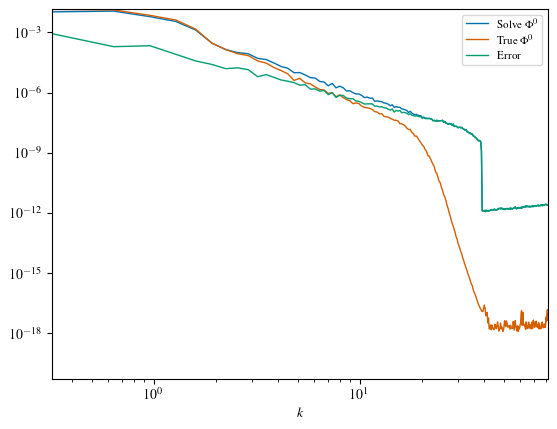

In [40]:
solvePhi0_spec = isospec_rfft( np.abs(params__)**2 )
press_truth_spec = isospec_rfft( np.abs(press_truth__)**2 )
Phi0error_spec = isospec_rfft( np.abs(press_truth__-params__)**2 )

k_ndim = np.arange(0,zetap1_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,solvePhi0_spec,label="Solve $\Phi^0$")
plt.loglog(k_ndim,press_truth_spec,label="True $\Phi^0$")
plt.loglog(k_ndim,Phi0error_spec,label="Error")

# plt.ylim([1e-7,1e-2])
plt.xlabel("$k$ ")
plt.legend()

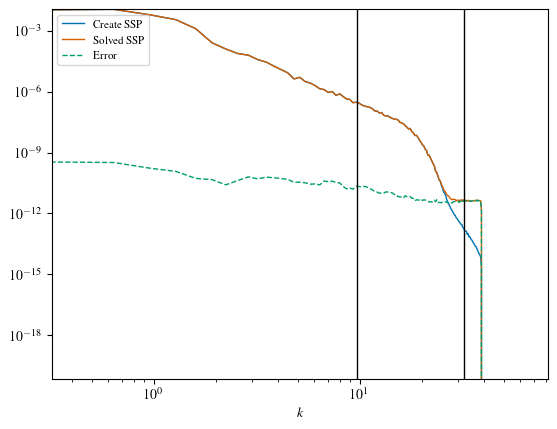

In [41]:
press_spec = isospec_rfft( np.abs(press_lpndim__)**2 )
params_spec = isospec_rfft( np.abs(params__)**2 )
totp1pres_spec = isospec_rfft( np.abs(totp1pres__)**2 )
err_spec = isospec_rfft( np.abs(press_lpndim__-totp1pres__)**2 )

k_ndim = np.arange(0,press_spec.size,1.)*(kx_Ld[1])
k_fac = kx_Ld[1]/(1/1e3)
plt.loglog(k_ndim,press_spec,label="Create SSP")
plt.loglog(k_ndim,totp1pres_spec,label="Solved SSP")
plt.loglog(k_ndim,err_spec,'--',label="Error")

# plt.loglog(k_ndim,k_ndim**(-const_slope)/const_eta/Ro**2,'k')

# plt.axvline(1/15*k_fac,color='k')
# plt.axvline(1/38*k_fac,color='k')
plt.axvline(1/33*k_fac,color='k')
plt.axvline(1/10*k_fac,color='k')

# plt.ylim([1e-16,1e3])
plt.xlabel("$k$ ")
plt.legend()

In [42]:
zeta_SQGp1__ = Ro*(eps*ZETAp1__(params__))
zeta_SQGp1__ = zeta_SQGp1__*lp_filter**1

zeta_Truth__ = rfft2(ds['zeta1'])*lp_filter**0
zeta_Truth = irfft2(zeta_Truth__)

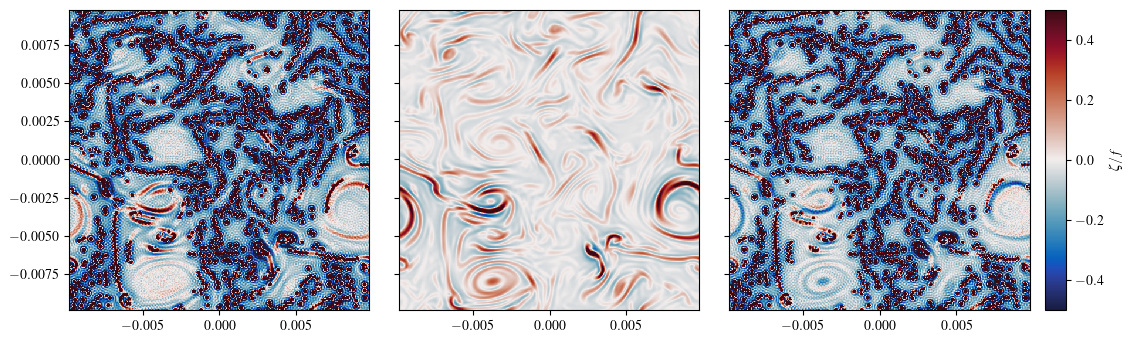

In [43]:
xl = 0; xh = -1
yl = 0; yh = -1
fig = plt.figure(figsize=(9*1.5, 2.6*1.5))

grid = ImageGrid(fig, 111,          # as in plt.subplot(111)
                 nrows_ncols=(1,3),
                 axes_pad=0.3,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="single",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )
cmax = 0.5

zeta_truth_crop = zeta_Truth*eps
zeta_GeoBal_crop = 0
zeta_SQGp1_crop = irfft2(zeta_SQGp1__)

im0 = grid[0].pcolor(x/1000,y/1000,zeta_SQGp1_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
im1 = grid[1].pcolor(x/1000,y/1000,zeta_truth_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
im2 = grid[2].pcolor(x/1000,y/1000,zeta_SQGp1_crop-zeta_truth_crop, cmap=cmo.balance, vmin=-cmax, vmax=cmax)
# grid[0].set_title(r"$\zeta^\textrm{Truth}-\zeta^\textrm{QG}$, $\sigma=%.3f$" %np.std(zeta_truth_crop-zeta_GeoBal_crop))

cbar = grid[2].cax.colorbar(im2)
cbar.set_label("$\zeta/f$")

# print(rel_err(zeta_truth_crop,zeta_SQGp1_crop))
# print(rel_err(zeta_truth_crop,zeta_GeoBal_crop))
# print(1-rel_err(zeta_truth_crop,zeta_SQGp1_crop)/rel_err(zeta_truth_crop,zeta_GeoBal_crop))

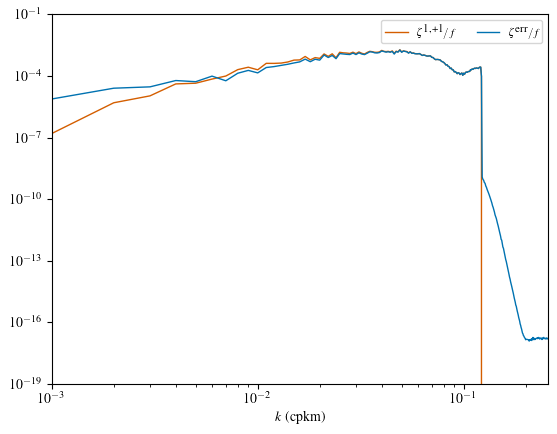

In [44]:
zeta_SQGp1_spec = isospec_rfft( np.abs(zeta_SQGp1__)**2 )

zeta_err__ = rfft2(zeta_SQGp1_crop-zeta_truth_crop)
zeta_err_spec = isospec_rfft( np.abs(zeta_err__)**2 )

plt.loglog(k_ndim/k_fac,zeta_SQGp1_spec,color=[0.83203125,0.3671875,0.],label=r"$\zeta^\textrm{1,+1}/f$")
plt.loglog(k_ndim/k_fac,zeta_err_spec,label=r"$\zeta^\textrm{err}/f$")


plt.ylim([1e-19,0.1])
plt.xlabel("$k$ (cpkm)")
plt.legend(ncol=2)